In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("genres_v2.csv", low_memory=False)

In [3]:
df.head()

df.shape

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22880 entries, 0 to 22879
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      22880 non-null  float64
 1   energy            22880 non-null  float64
 2   key               22880 non-null  int64  
 3   loudness          22880 non-null  float64
 4   mode              22880 non-null  int64  
 5   speechiness       22880 non-null  float64
 6   acousticness      22880 non-null  float64
 7   instrumentalness  22880 non-null  float64
 8   liveness          22880 non-null  float64
 9   valence           22880 non-null  float64
 10  tempo             22880 non-null  float64
 11  type              22880 non-null  object 
 12  id                22880 non-null  object 
 13  uri               22880 non-null  object 
 14  track_href        22880 non-null  object 
 15  analysis_url      22879 non-null  object 
 16  duration_ms       22879 non-null  float6

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,Unnamed: 0
count,22880.000000,22880.000000,22880.000000,22880.000000,22880.000000,22880.000000,22880.000000,22880.000000,22880.000000,22880.000000,22880.000000,22879.000000,22879.000000,1354.000000
mean,0.681203,0.667665,5.182692,-7.040335,0.582736,0.171840,0.158130,0.106220,0.191781,0.425998,149.905487,200414.152017,3.970191,683.867061
std,0.157871,0.178392,3.703996,2.857971,0.493118,0.139043,0.205637,0.258437,0.150988,0.236070,28.954115,66927.689222,0.316357,394.798140
min,0.065100,0.000243,0.000000,-33.357000,0.000000,0.022700,0.000001,0.000000,0.010700,0.020600,57.967000,38333.000000,1.000000,0.000000
25%,0.576000,0.542000,1.000000,-8.616000,0.000000,0.055400,0.012300,0.000000,0.098900,0.229000,126.019750,153152.000000,4.000000,341.250000
50%,0.707000,0.670000,5.000000,-6.703000,1.000000,0.120000,0.068400,0.000002,0.127000,0.412000,145.965000,194333.000000,4.000000,686.500000
75%,0.802000,0.807000,8.000000,-5.101000,1.000000,0.268000,0.223000,0.003255,0.242000,0.605000,171.979250,235200.000000,4.000000,1024.750000
max,0.988000,0.999000,11.000000,3.148000,1.000000,0.946000,0.988000,0.989000,0.973000,0.980000,220.290000,728413.000000,5.000000,1366.000000


In [7]:
df.isnull().sum()


,0
danceability,0
energy,0
key,0
loudness,0
mode,0
speechiness,0
acousticness,0
instrumentalness,0
liveness,0
valence,0


In [6]:

columns_to_drop = [
    'type',
    'id',
    'uri',
    'track_href',
    'analysis_url',
    'Unnamed: 0'
]

df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

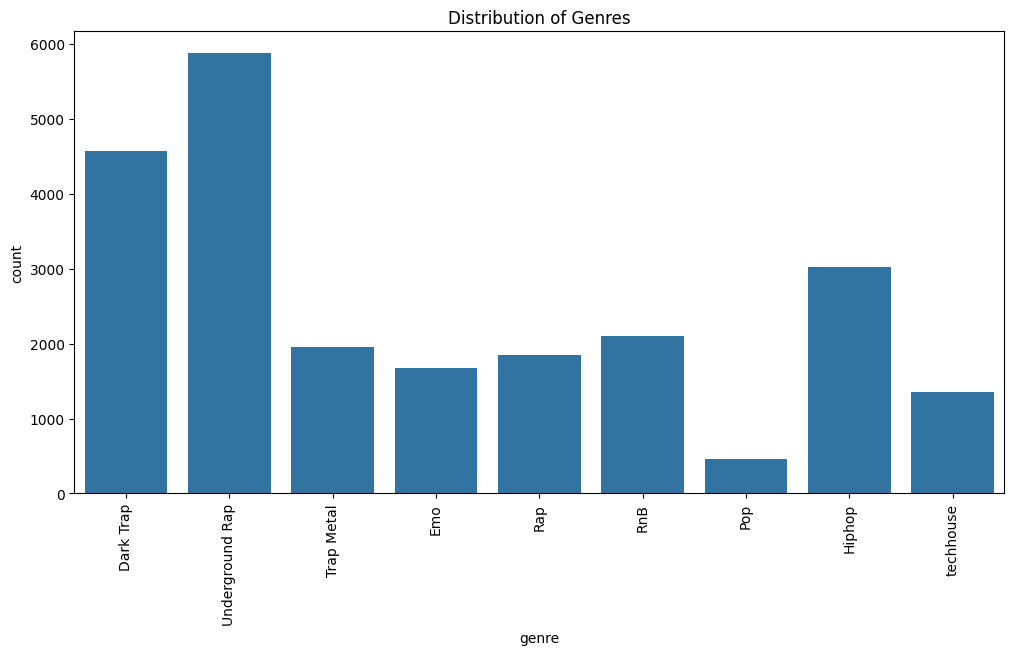

In [8]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='genre')
plt.xticks(rotation=90)
plt.title("Distribution of Genres")
plt.show()

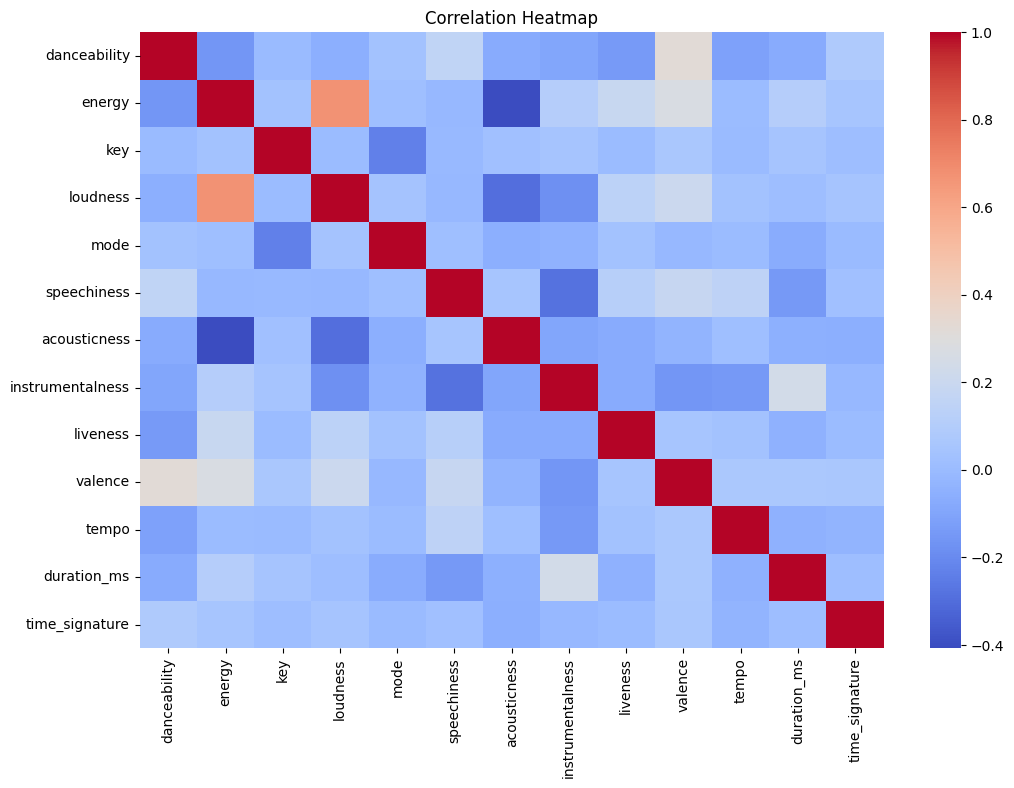

In [9]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

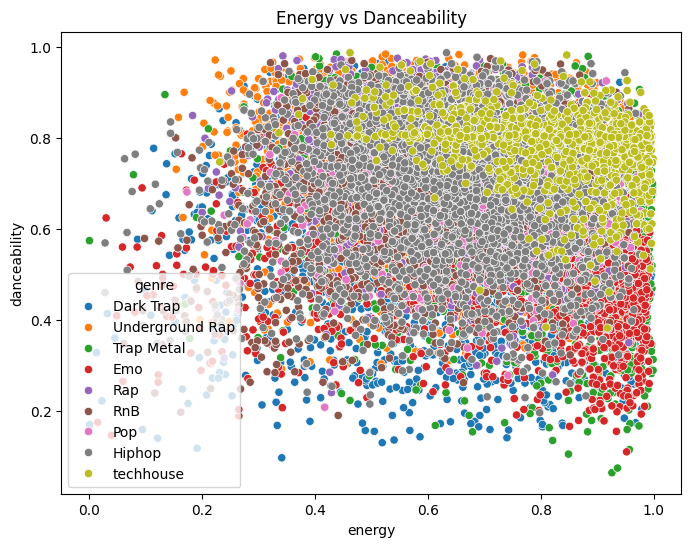

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,
                x='energy',
                y='danceability',
                hue='genre')

plt.title("Energy vs Danceability")
plt.show()

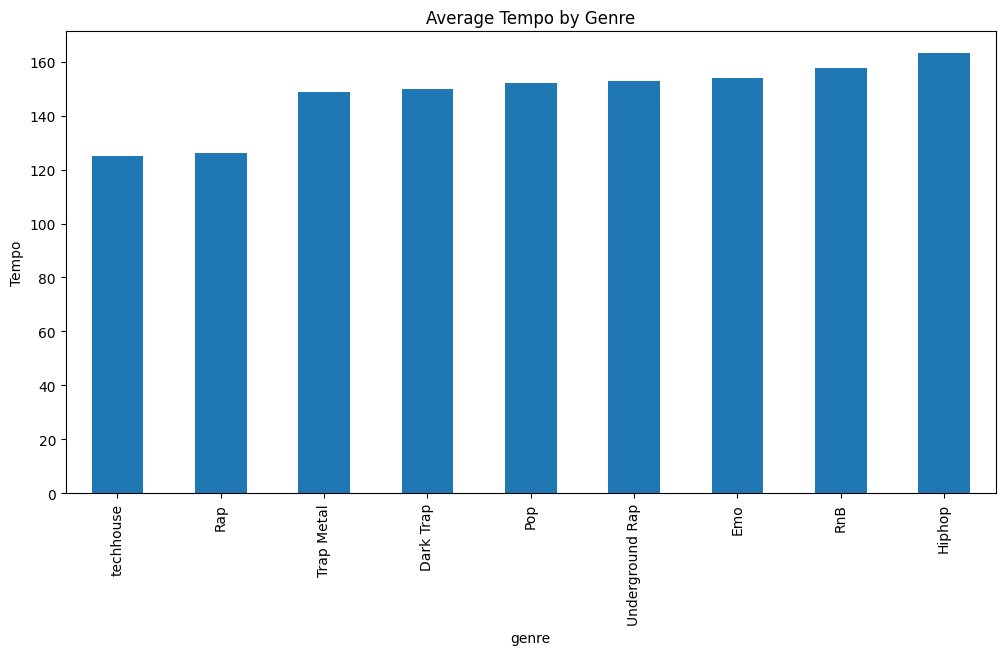

In [11]:
genre_tempo = df.groupby('genre')['tempo'].mean().sort_values()

genre_tempo.plot(kind='bar', figsize=(12,6))
plt.title("Average Tempo by Genre")
plt.ylabel("Tempo")
plt.show()

Insights
1. Genres with higher energy often show higher danceability.
2. Acoustic tracks tend to have lower loudness.
3. Certain genres have significantly faster tempos.
4. Instrumentalness is strongly genre-dependent.
5. Some audio features are highly correlated.